In [26]:
import pandas as pd 
from tensorflow.keras.layers import Dense, Dropout, Activation 
from tensorflow.keras.models import Model, Sequential 
from tensorflow.keras.optimizers import Adam 


data = pd.read_csv('Datasets/Google.csv')

In [27]:
data.head(2)

,Open,High,Low,Close,Volume
0,325,333,325,664,7380500
1,331,334,329,666,5749400


In [28]:
data.isnull().sum()

Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [29]:
X = data.drop(['Open'], axis=1).values
Y = data[['Open']].values

In [30]:
Y.shape

(1258, 1)

In [31]:
from sklearn.model_selection import train_test_split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=35)

def create_model(learning_rate, dropout_rate):
    model = Sequential()
    model.add(Dense(100, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(50, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(25, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    adam=Adam(lr=learning_rate)
    model.compile(loss='mean_squared_error', optimizer=adam, metrics=['mae'])
    return model

In [34]:
epochs = 1000
learning_rate = 0.01
validation = (X_test, Y_test)
dropout_rate = 0.02

In [35]:

model = create_model(learning_rate, dropout_rate)
model_history = model.fit(X_train, Y_train, batch_size=20, epochs=epochs, validation_split=0.1, verbose=2)

Epoch 1/1000
46/46 - 1s - loss: 17573201920.0000 - mae: 71710.7031 - val_loss: 92535432.0000 - val_mae: 7845.6553 - 939ms/epoch - 20ms/step
Epoch 2/1000
46/46 - 0s - loss: 881090752.0000 - mae: 16120.4941 - val_loss: 67970792.0000 - val_mae: 7088.9077 - 233ms/epoch - 5ms/step
Epoch 3/1000
46/46 - 0s - loss: 174440224.0000 - mae: 6767.3032 - val_loss: 2837243.0000 - val_mae: 1201.9200 - 242ms/epoch - 5ms/step
Epoch 4/1000
46/46 - 0s - loss: 137124176.0000 - mae: 5775.9082 - val_loss: 68737968.0000 - val_mae: 7129.4902 - 224ms/epoch - 5ms/step
Epoch 5/1000
46/46 - 0s - loss: 126233000.0000 - mae: 5654.9570 - val_loss: 163209.2344 - val_mae: 340.7528 - 227ms/epoch - 5ms/step
Epoch 6/1000
46/46 - 0s - loss: 64411392.0000 - mae: 3837.1584 - val_loss: 1065568.1250 - val_mae: 728.4493 - 227ms/epoch - 5ms/step
Epoch 7/1000
46/46 - 0s - loss: 48235496.0000 - mae: 3888.1821 - val_loss: 1725212.5000 - val_mae: 924.3831 - 228ms/epoch - 5ms/step
Epoch 8/1000
46/46 - 0s - loss: 48007748.0000 - mae: 

In [9]:
print(model_history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


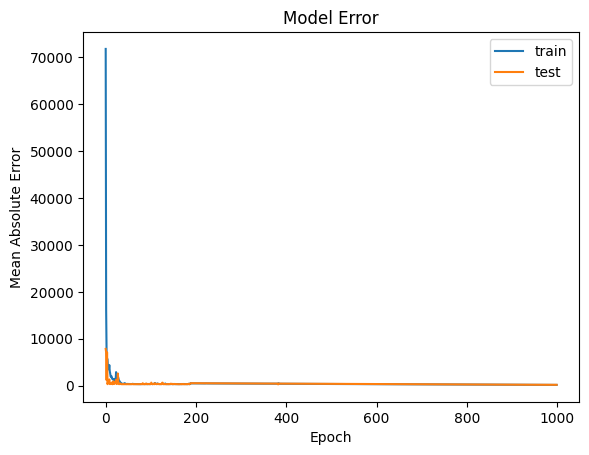

In [36]:
import matplotlib.pyplot as plt 

plt.plot(model_history.history['mae'])
plt.plot(model_history.history['val_mae'])
plt.legend(['train', 'test'], loc='upper right')
plt.title('Model Error')
plt.ylabel('Mean Absolute Error')
plt.xlabel('Epoch')
plt.show()

In [39]:
X.shape

(1258, 4)

In [40]:
import numpy as np

# create numpy array of random numbers as new variable to test new model
randnums = np.random.randint(1, 30, size=(500, 4))

# convert new variables to list
list = randnums.tolist()

# run new variables through model
prediction = model.predict(list)

16/16 [==============================] - 0s 2ms/step


In [41]:
# output model predictions 
print('Google Stock Predictions (Open Price) with new data:', prediction)

Google Stock Predictions (Open Price) with new data: [[377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]
 [377.3241]

In [11]:
# Model Accuracy
#plt.plot(model_history.history['categorical_accuracy'])
#plt.plot(model_history.history['val_categorical_accuracy'])
#plt.title('model accuracy')
#plt.ylabel('accuracy')
#plt.xlabel('epoch')
#plt.legend(['train', 'test'], loc='upper left')
#plt.show()

In [12]:
# Model Loss
#plt.plot(model_history.history['loss'])
#plt.plot(model_history.history['val_loss'])
#plt.title('Model Loss')
#plt.ylabel('Loss')
#plt.xlabel('Epoch')
#plt.legend(['Training', 'Validation'], loc='upper right')

#plt.tight_layout()

In [ ]:
randnums= np.random.randint(1,101,5)